In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv(r"C:\Users\91727\OneDrive\Desktop\logistics_delivery_cleaned.csv")

In [3]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print(df.columns.tolist())

Rows: 25000
Columns: 18
['delivery_id', 'delivery_partner', 'package_type', 'vehicle_type', 'delivery_mode', 'region', 'weather_condition', 'distance_km', 'package_weight_kg', 'delivery_time_hours', 'expected_time_hours', 'delayed', 'delivery_status', 'delivery_rating', 'delivery_cost', 'distance_km_normalized', 'package_weight_kg_normalized', 'delivery_cost_normalized']


In [4]:
df.head()

,delivery_id,delivery_partner,package_type,vehicle_type,delivery_mode,region,weather_condition,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delayed,delivery_status,delivery_rating,delivery_cost,distance_km_normalized,package_weight_kg_normalized,delivery_cost_normalized
0,250.99,delhivery,automobile parts,bike,same day,west,clear,297.0,46.96,8,8,no,delivered,3,1632.7206,0.999659,0.947595,1.000000
1,250.99,xpressbees,cosmetics,ev van,express,central,cold,89.6,47.39,2,3,no,delivered,5,640.1700,0.293015,0.956397,0.354251
2,250.99,shadowfax,groceries,truck,two day,east,rainy,273.5,26.89,10,16,no,delivered,4,1448.1700,0.919591,0.536745,0.879932
3,250.99,dhl,electronics,ev van,same day,east,cold,269.7,12.69,6,8,no,delivered,3,1486.5700,0.906644,0.246059,0.904915
4,250.99,dhl,clothing,van,two day,north,foggy,256.7,37.02,9,16,no,delivered,4,1394.5600,0.862351,0.744115,0.845054


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 18 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   delivery_id                   25000 non-null  float64
 1   delivery_partner              25000 non-null  object 
 2   package_type                  25000 non-null  object 
 3   vehicle_type                  25000 non-null  object 
 4   delivery_mode                 25000 non-null  object 
 5   region                        25000 non-null  object 
 6   weather_condition             25000 non-null  object 
 7   distance_km                   25000 non-null  float64
 8   package_weight_kg             25000 non-null  float64
 9   delivery_time_hours           25000 non-null  int64  
 10  expected_time_hours           25000 non-null  int64  
 11  delayed                       25000 non-null  object 
 12  delivery_status               25000 non-null  object 
 13  d

In [6]:
df.describe()

,delivery_id,distance_km,package_weight_kg,delivery_time_hours,expected_time_hours,delivery_rating,delivery_cost,distance_km_normalized,package_weight_kg_normalized,delivery_cost_normalized
count,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000,25000.000000
mean,12500.500000,150.390436,25.145898,6.248040,13.107680,3.666000,864.944579,0.500138,0.501042,0.500488
std,7212.732314,86.409745,14.368663,3.140935,7.559024,1.149964,435.712593,0.294411,0.294138,0.283473
min,250.990000,3.600000,0.670000,0.000000,2.000000,1.000000,95.667400,0.000000,0.000000,0.000000
25%,6250.750000,75.900000,12.680000,4.000000,8.000000,3.000000,490.800000,0.246337,0.245855,0.257072
50%,12500.500000,151.000000,25.145000,6.000000,8.000000,4.000000,867.535000,0.502215,0.501024,0.502174
75%,18750.250000,224.900000,37.660000,8.000000,16.000000,5.000000,1237.910000,0.754003,0.757216,0.743138
max,24750.010000,297.100000,49.520000,19.000000,24.000000,5.000000,1632.720600,1.000000,1.000000,1.000000


In [7]:
print("Total missing values:" , df.isnull().sum().sum())

Total missing values: 0


In [8]:
print("===== KEY LOGISTICS KPIs =====")

delay_rate = (df["delayed"] == "yes").mean() * 100

print("Overall Delay Rate:", round(delay_rate, 2), "%")
print("Average Delivery Time:",
      round(df["delivery_time_hours"].mean(), 2), "hours")
print("Average Expected Time:",
      round(df["expected_time_hours"].mean(), 2), "hours")
print("Average Delivery Cost:",
      round(df["delivery_cost"].mean(), 2))
print("Average Delivery Rating:",
      round(df["delivery_rating"].mean(), 2))

===== KEY LOGISTICS KPIs =====
Overall Delay Rate: 26.68 %
Average Delivery Time: 6.25 hours
Average Expected Time: 13.11 hours
Average Delivery Cost: 864.94
Average Delivery Rating: 3.67


In [9]:
print("===== DELIVERY STATUS =====")
print(df["delivery_status"].value_counts())

===== DELIVERY STATUS =====
delivery_status
delivered    18331
delayed       5341
failed        1328
Name: count, dtype: int64


In [10]:
print("===== DELAY STATUS =====")
print(df["delayed"].value_counts())

===== DELAY STATUS =====
delayed
no     18331
yes     6669
Name: count, dtype: int64


In [11]:
delay_by_mode = (
    df.groupby("delivery_mode")["delayed"]
      .apply(lambda x: (x == "yes").mean() * 100)
      .sort_values(ascending=False)
)

print(delay_by_mode)

delivery_mode
express     73.784694
same day    32.537028
two day      0.428435
standard     0.000000
Name: delayed, dtype: float64


In [12]:
avg_time_by_mode = (
    df.groupby("delivery_mode")["delivery_time_hours"]
      .mean()
      .sort_values(ascending=False)
)

print(avg_time_by_mode)

delivery_mode
two day     6.278642
same day    6.244784
standard    6.237472
express     6.230868
Name: delivery_time_hours, dtype: float64


In [13]:
mode_counts = df["delivery_mode"].value_counts()

print(mode_counts)

delivery_mode
two day     6302
same day    6279
express     6233
standard    6186
Name: count, dtype: int64


In [14]:
mode_summary = df.groupby("delivery_mode").agg(
    total_deliveries=("delivery_mode", "count"),
    delayed_deliveries=("delayed",lambda x: (x == "yes").sum()),
    avg_delivery_time=("delivery_time_hours","mean"),
    avg_delivery_cost=("delivery_cost","mean")
)

mode_summary["delay_rate"] = (
    mode_summary["delayed_deliveries"]
    / mode_summary["total_deliveries"]
    *100
)

print(mode_summary.sort_values("delay_rate", ascending=False))

               total_deliveries  delayed_deliveries  avg_delivery_time  \
delivery_mode                                                            
express                    6233                4599           6.230868   
same day                   6279                2043           6.244784   
two day                    6302                  27           6.278642   
standard                   6186                   0           6.237472   

               avg_delivery_cost  delay_rate  
delivery_mode                                 
express               880.426426   73.784694  
same day              929.872468   32.537028  
two day               829.710800    0.428435  
standard              819.335575    0.000000  


In [15]:
df["time_difference"] = (
    df["delivery_time_hours"] -
    df["expected_time_hours"]
)

print(df["time_difference"].describe())

count    25000.000000
mean        -6.859640
std          8.069482
min        -24.000000
25%        -14.000000
50%         -6.000000
75%          0.000000
max         12.000000
Name: time_difference, dtype: float64


In [16]:
print(
    "Deliveries where actual time > expected time:",
    (df["time_difference"] > 0).sum()
)

print(
    "Deliveries where actual time <= expected time:",
    (df["time_difference"] <= 0).sum()
)

Deliveries where actual time > expected time: 5466
Deliveries where actual time <= expected time: 19534


In [17]:
comparison = pd.crosstab(
    df["time_difference"] > 0,
    df["delayed"],
    margins=True
)

print(comparison)

delayed             no   yes    All
time_difference                    
False            18331  1203  19534
True                 0  5466   5466
All              18331  6669  25000


In [18]:
inconsistent_delays = df[
    (df["time_difference"] <= 0) &
    (df["delayed"] == "yes")
]

print("Inconsistent delayed records:", len(inconsistent_delays))

print(inconsistent_delays[[
    "delivery_time_hours",
    "expected_time_hours",
    "time_difference",
    "delayed",
    "delivery_status",
    "delivery_mode",
    "distance_km",
    "weather_condition"
]].head(20))

Inconsistent delayed records: 1203
     delivery_time_hours  expected_time_hours  time_difference delayed  \
79                     3                    3                0     yes   
80                     8                    8                0     yes   
140                    8                    8                0     yes   
155                    8                    8                0     yes   
202                    3                    3                0     yes   
209                    8                    8                0     yes   
219                    6                    6                0     yes   
229                    2                    2                0     yes   
239                    7                    7                0     yes   
248                    8                    8                0     yes   
250                    3                    3                0     yes   
264                    4                    4                0     yes   
269

In [19]:
print(inconsistent_delays["delivery_status"].value_counts())

delivery_status
delayed    963
failed     240
Name: count, dtype: int64


In [20]:
print(inconsistent_delays["delivery_mode"].value_counts())

delivery_mode
same day    619
express     568
two day      16
Name: count, dtype: int64


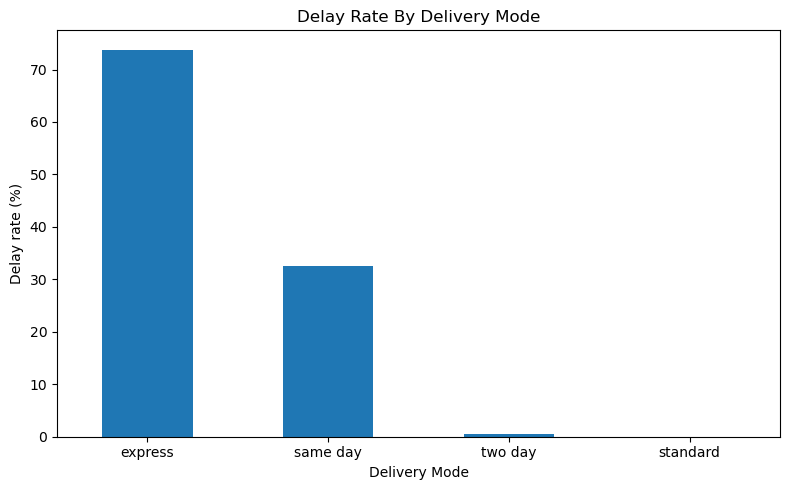

In [21]:
plt.figure(figsize=(8,5))

delay_by_mode.plot(kind="bar")

plt.title("Delay Rate By Delivery Mode")
plt.xlabel("Delivery Mode")
plt.ylabel("Delay rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

In [22]:
partner_summary = df.groupby("delivery_partner").agg(
    total_deliveries=("delivery_partner", "count"),
    delayed_deliveries=("delayed", lambda x: (x == "yes").sum()),
    avg_delivery_time=("delivery_time_hours", "mean"),
    avg_delivery_cost=("delivery_cost", "mean"),
    avg_rating=("delivery_rating", "mean")
)

partner_summary["delay_rate"] = (
    partner_summary["delayed_deliveries"]
    / partner_summary["total_deliveries"]
    * 100
)

partner_summary = partner_summary.sort_values(
    "delay_rate",
    ascending=False
)

print(partner_summary)

                  total_deliveries  delayed_deliveries  avg_delivery_time  \
delivery_partner                                                            
xpressbees                    2826                 799           6.323779   
ekart                         2801                 768           6.268119   
shadowfax                     2736                 747           6.272295   
amazon logistics              2711                 738           6.279233   
blue dart                     2798                 754           6.296283   
ecom express                  2722                 725           6.246877   
dhl                           2802                 738           6.250535   
fedex                         2818                 709           6.140880   
delhivery                     2786                 691           6.155420   

                  avg_delivery_cost  avg_rating  delay_rate  
delivery_partner                                             
xpressbees               868

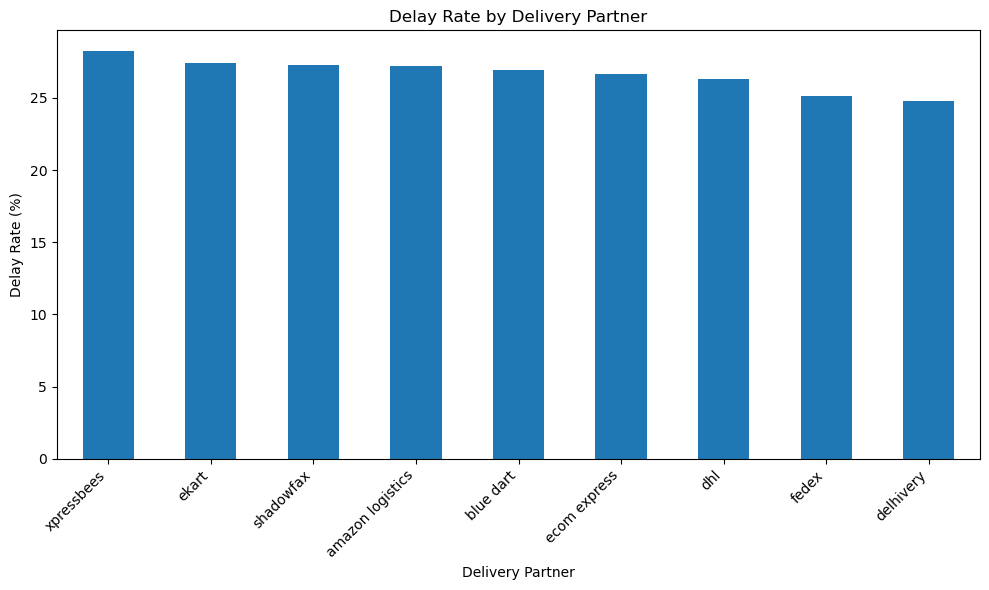

In [23]:
plt.figure(figsize=(10, 6))

partner_summary["delay_rate"].plot(kind="bar")

plt.title("Delay Rate by Delivery Partner")
plt.xlabel("Delivery Partner")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [24]:
weather_summary = df.groupby("weather_condition").agg(
    total_deliveries=("weather_condition", "count"),
    delayed_deliveries=("delayed", lambda x: (x == "yes").sum()),
    avg_delivery_time=("delivery_time_hours", "mean"),
    avg_delivery_cost=("delivery_cost", "mean")
)

weather_summary["delay_rate"] = (
    weather_summary["delayed_deliveries"]
    / weather_summary["total_deliveries"]
    * 100
)

weather_summary = weather_summary.sort_values(
    "delay_rate",
    ascending=False
)

print(weather_summary)

                   total_deliveries  delayed_deliveries  avg_delivery_time  \
weather_condition                                                            
stormy                         4198                1740           8.807527   
rainy                          4171                1558           7.804843   
foggy                          4219                1279           6.486608   
clear                          4124                 719           4.776431   
hot                            4130                 707           4.784504   
cold                           4158                 666           4.773449   

                   avg_delivery_cost  delay_rate  
weather_condition                                 
stormy                    859.247482   41.448309  
rainy                     867.469355   37.353153  
foggy                     862.682236   30.315241  
clear                     865.366973   17.434530  
hot                       868.231080   17.118644  
cold              

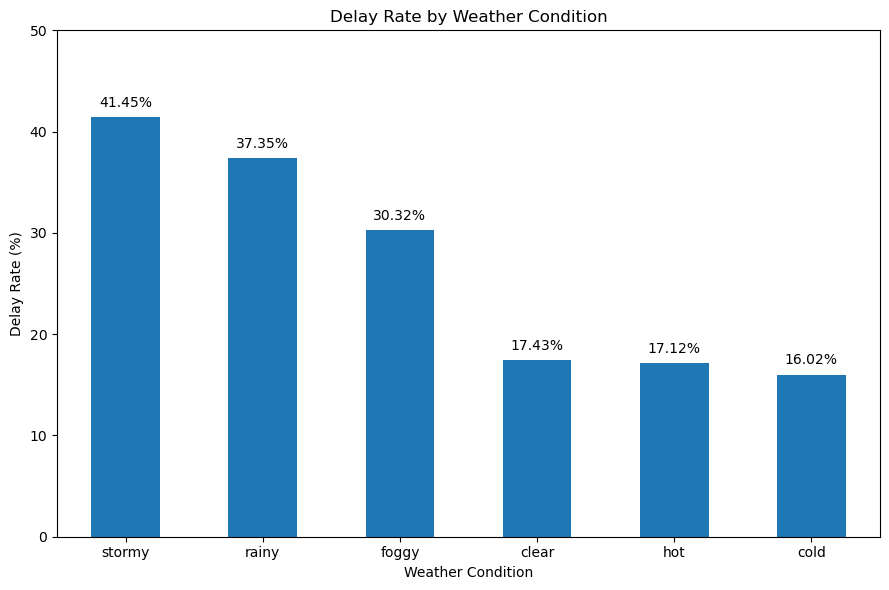

In [25]:
plt.figure(figsize=(9, 6))

ax = weather_summary["delay_rate"].plot(kind="bar")

plt.title("Delay Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(weather_summary["delay_rate"]):
    ax.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.ylim(0, 50)
plt.tight_layout()
plt.show()

In [26]:
distance_bins = pd.cut(
    df["distance_km"],
    bins=[0, 50, 100, 150, 200, 250, 300],
    labels=["0-50", "50-100", "100-150", "150-200", "200-250", "250-300"]
)

distance_summary = df.groupby(distance_bins, observed=True).agg(
    total_deliveries=("distance_km", "count"),
    avg_delivery_time=("delivery_time_hours", "mean"),
    avg_delivery_cost=("delivery_cost", "mean"),
    delay_rate=("delayed", lambda x: (x == "yes").mean() * 100)
)

print(distance_summary)

             total_deliveries  avg_delivery_time  avg_delivery_cost  \
distance_km                                                           
0-50                     4101           3.104609         239.635191   
50-100                   4216           4.387097         488.497661   
100-150                  4102           5.624086         737.511246   
150-200                  4313           6.904939         988.635901   
200-250                  4054           8.040701        1239.570242   
250-300                  4214           9.379449        1487.159203   

             delay_rate  
distance_km              
0-50          17.020239  
50-100        19.117647  
100-150       23.939542  
150-200       28.054718  
200-250       32.979773  
250-300       38.822971  


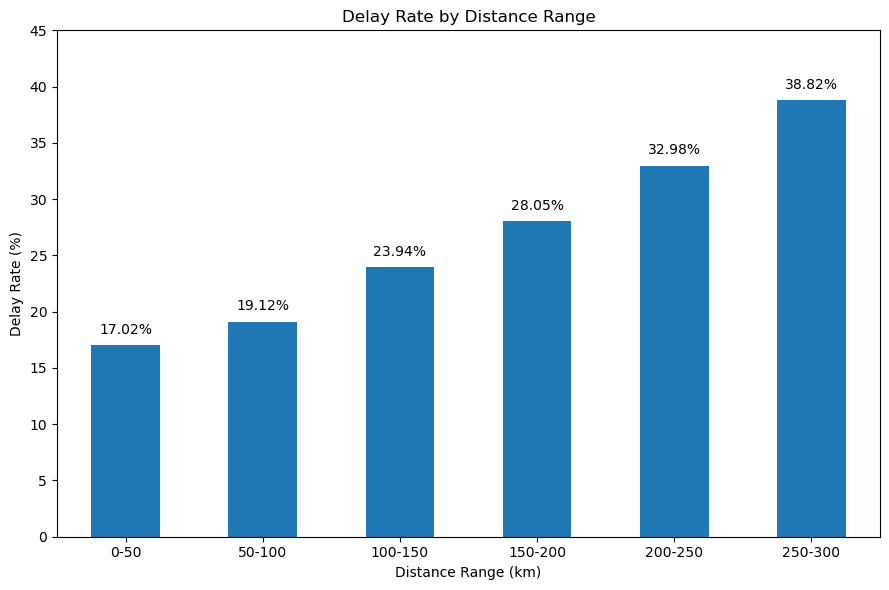

In [27]:
plt.figure(figsize=(9, 6))

ax = distance_summary["delay_rate"].plot(kind="bar")

plt.title("Delay Rate by Distance Range")
plt.xlabel("Distance Range (km)")
plt.ylabel("Delay Rate (%)")
plt.xticks(rotation=0)

for i, value in enumerate(distance_summary["delay_rate"]):
    ax.text(i, value + 1, f"{value:.2f}%", ha="center")

plt.ylim(0, 45)
plt.tight_layout()
plt.show()

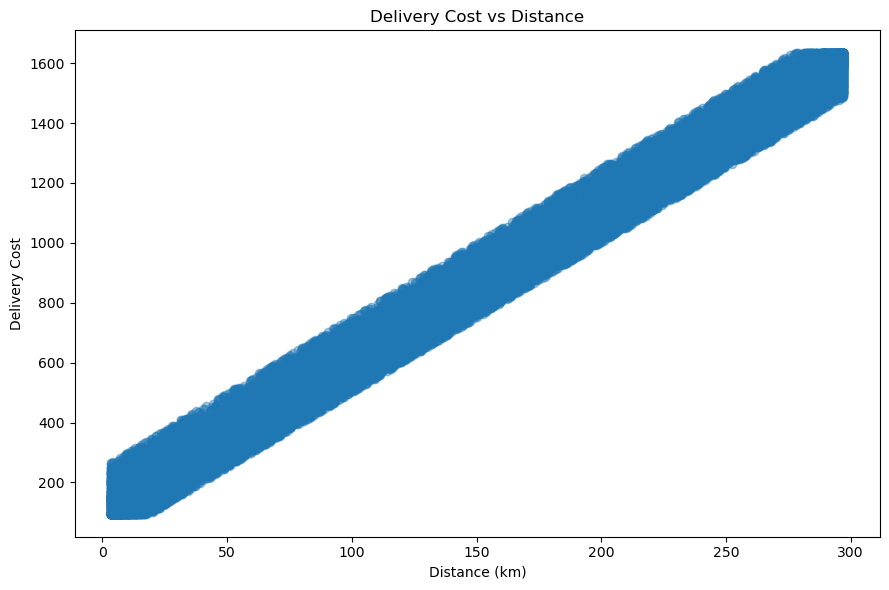

In [28]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["distance_km"],
    df["delivery_cost"],
    alpha=0.4
)

plt.title("Delivery Cost vs Distance")
plt.xlabel("Distance (km)")
plt.ylabel("Delivery Cost")

plt.tight_layout()
plt.show()

In [29]:
correlation = df[[
    "distance_km",
    "package_weight_kg",
    "delivery_time_hours",
    "expected_time_hours",
    "delivery_cost",
    "delivery_rating"
]].corr()

print(correlation.round(2))

                     distance_km  package_weight_kg  delivery_time_hours  \
distance_km                 1.00                0.0                 0.69   
package_weight_kg           0.00                1.0                 0.00   
delivery_time_hours         0.69                0.0                 1.00   
expected_time_hours         0.05                0.0                 0.04   
delivery_cost               0.99                0.1                 0.68   
delivery_rating            -0.13               -0.0                -0.27   

                     expected_time_hours  delivery_cost  delivery_rating  
distance_km                         0.05           0.99            -0.13  
package_weight_kg                   0.00           0.10            -0.00  
delivery_time_hours                 0.04           0.68            -0.27  
expected_time_hours                 1.00          -0.03             0.46  
delivery_cost                      -0.03           1.00            -0.16  
delivery_rating  

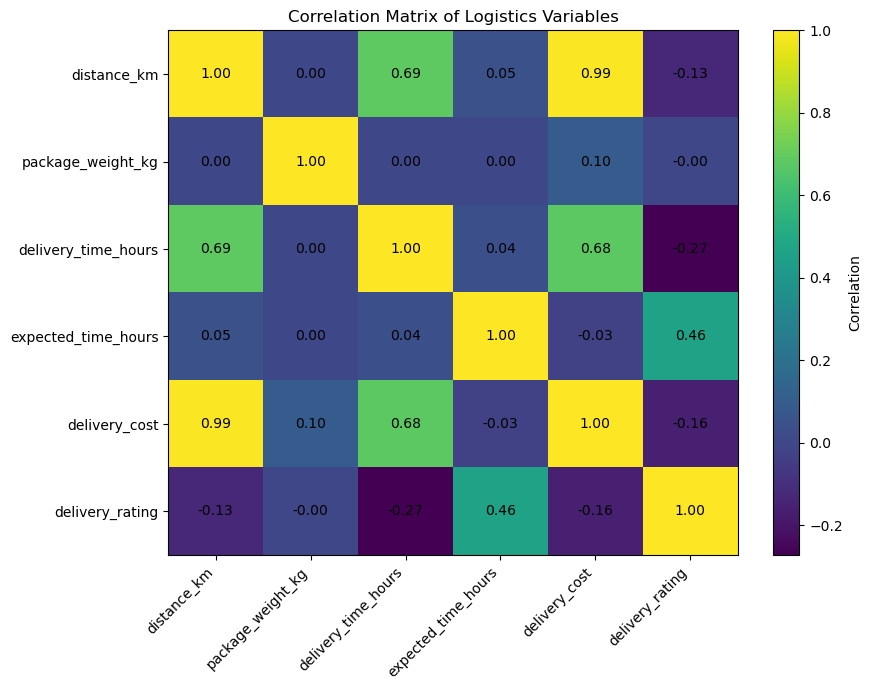

In [30]:
plt.figure(figsize=(9, 7))

plt.imshow(correlation, aspect="auto")

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation.columns)),
    correlation.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(correlation.columns)),
    correlation.columns
)

for i in range(len(correlation.columns)):
    for j in range(len(correlation.columns)):
        plt.text(
            j,
            i,
            f"{correlation.iloc[i, j]:.2f}",
            ha="center",
            va="center"
        )

plt.title("Correlation Matrix of Logistics Variables")
plt.tight_layout()
plt.show()

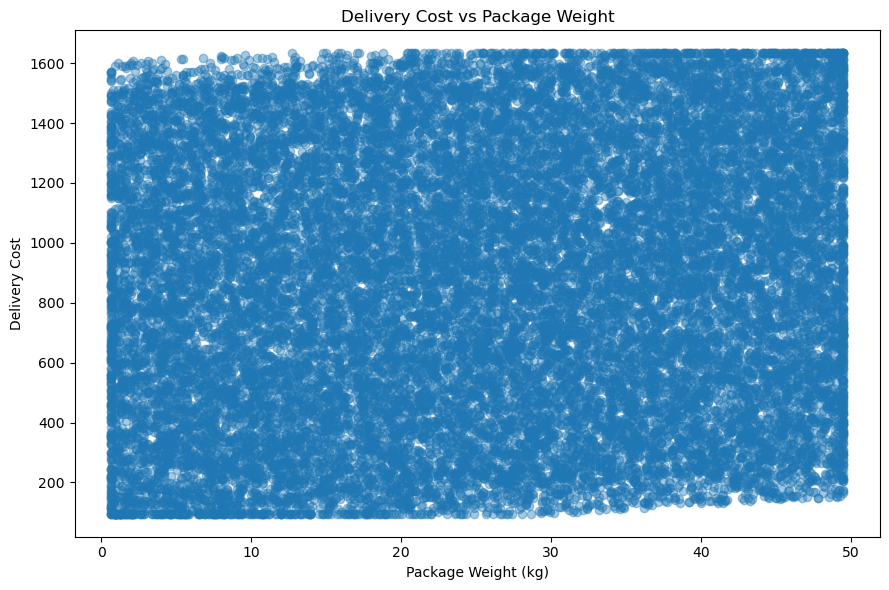

In [31]:
plt.figure(figsize=(9, 6))

plt.scatter(
    df["package_weight_kg"],
    df["delivery_cost"],
    alpha=0.4
)

plt.title("Delivery Cost vs Package Weight")
plt.xlabel("Package Weight (kg)")
plt.ylabel("Delivery Cost")

plt.tight_layout()
plt.show()

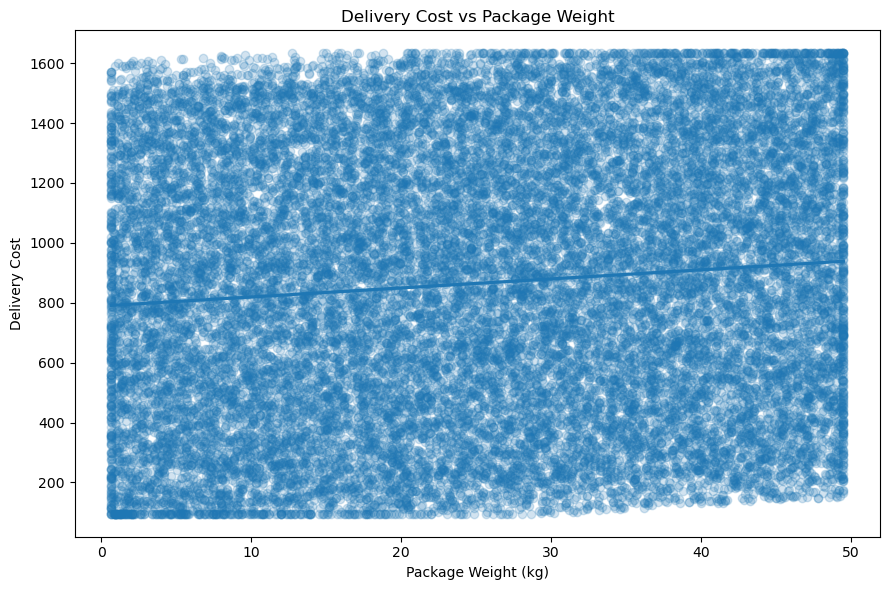

In [32]:
plt.figure(figsize=(9, 6))

sns.regplot(
    data=df,
    x="package_weight_kg",
    y="delivery_cost",
    scatter_kws={"alpha": 0.2},
    line_kws={}
)

plt.title("Delivery Cost vs Package Weight")
plt.xlabel("Package Weight (kg)")
plt.ylabel("Delivery Cost")
plt.tight_layout()
plt.show()

In [33]:
rating_by_mode = df.groupby("delivery_mode")["delivery_rating"].mean().sort_values(ascending=False)

print(rating_by_mode)

delivery_mode
standard    4.218558
two day     4.184545
same day    3.543399
express     2.716830
Name: delivery_rating, dtype: float64


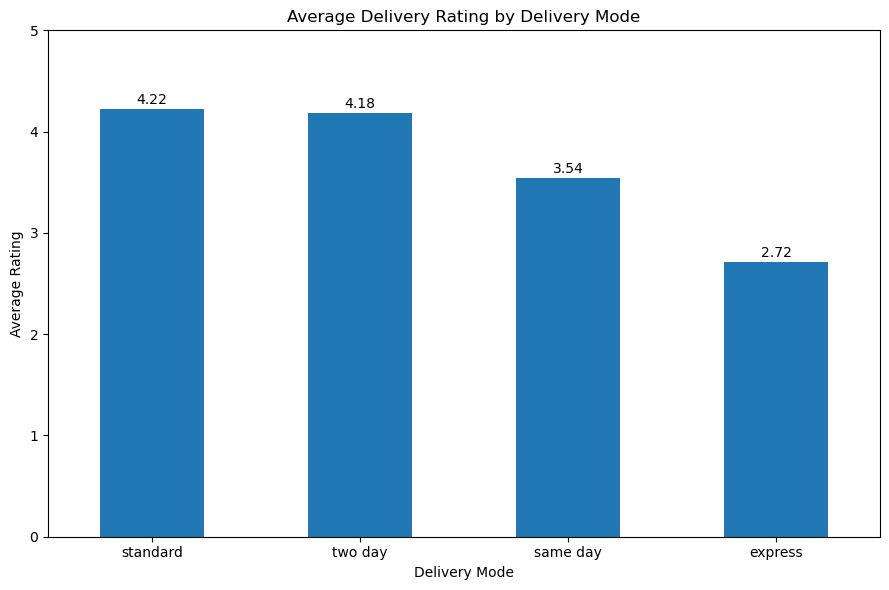

In [34]:
plt.figure(figsize=(9, 6))

ax = rating_by_mode.plot(kind="bar")

plt.title("Average Delivery Rating by Delivery Mode")
plt.xlabel("Delivery Mode")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)

for i, value in enumerate(rating_by_mode):
    ax.text(i, value + 0.05, f"{value:.2f}", ha="center")

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [35]:
rating_by_delay = df.groupby("delayed")["delivery_rating"].agg(
    ["count", "mean"]
)

print(rating_by_delay)

         count      mean
delayed                 
no       18331  4.205172
yes       6669  2.183986


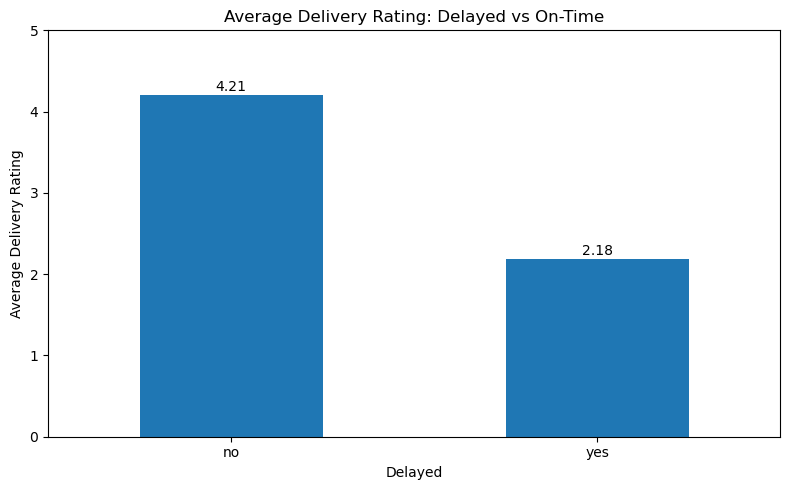

In [36]:
plt.figure(figsize=(8, 5))

ax = rating_by_delay["mean"].plot(kind="bar")

plt.title("Average Delivery Rating: Delayed vs On-Time")
plt.xlabel("Delayed")
plt.ylabel("Average Delivery Rating")
plt.xticks(rotation=0)

for i, value in enumerate(rating_by_delay["mean"]):
    ax.text(i, value + 0.05, f"{value:.2f}", ha="center")

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

In [37]:
mode_weather = pd.crosstab(
    df["delivery_mode"],
    df["weather_condition"],
    values=df["delayed"].eq("yes"),
    aggfunc="mean"
) * 100

print(mode_weather.round(2))

weather_condition  clear   cold  foggy    hot  rainy  stormy
delivery_mode                                               
express            51.57  52.89  89.35  52.03  97.71   99.81
same day           16.46  11.82  34.83  15.10  52.37   65.59
standard            0.00   0.00   0.00   0.00   0.00    0.00
two day             0.00   0.00   0.09   0.00   0.28    2.13
